In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io.wavfile as wav
from files.utils import ctft
from IPython.display import Audio         # Βιβλιοθήκη παιξίματος αρχείων ήχου
%matplotlib inline

## Άσκηση - Μετασχηματισμός Fourier και Παθολογίες Φωνής

Ο μετασχηματισμός Fourier είναι ένα   **ασύλληπτα**   χρήσιμο εργαλείο σε πολλούς τομείς της Επεξεργασίας Σήματος. 

Ένας τέτοιος τομέας είναι η **ανίχνευση παθολογίας φωνής**.


Ηχογραφήστε τη φωνή σας όταν εκφέρετε το φώνημα /α/, σταθερά, για περίπου $3-4$ δευτερόλεπτα. Φροντίστε να βρίσκεστε σε ήσυχο περιβάλλον, και προσπαθήστε (αν γίνεται) να χρησιμοποιήσετε κανονικό μικρόφωνο (αλλιώς, χρησιμοποιήστε τα ενσωματωμένα των laptops σας). 

Χρησιμοποιήστε ένα πρόγραμμα ηχογράφησης της επιλογής σας (π.χ. το δωρεάν πρόγραμμα Wavesurfer ή το Audacity) και φροντίστε η ηχογράφηση να είναι μονοφωνική (δηλ. όχι στέρεο - δικαναλική) και να γίνει σε συχνότητα δειγματοληψίας $16000$ Hz, και ακρίβεια αποθήκευσης $16$ bits σε μορφή $\texttt{.wav}$. 

**Σας δίνεται και ένα ενδεικτικό σήμα μαζί με την άσκηση, αν δεν μπορέσετε να πραγματοποιήσετε τα παραπάνω.**

---

Χρησιμοποιήστε τον κώδικα ανάλυσης μετασχηματισμού Fourier που σας δίνεται σε ξεχωριστό αρχείο ``utils.py`` ως συνάρτηση $\texttt{ctft}$.

In [2]:
help(ctft)

Help on function ctft in module files.utils:

ctft(ss, tt, ff, plot=True)
    Συνάρτηση που υπολογίζει το μετασχ. Fourier ενός σήματος
    Ορίσματα: ss : σήμα στο χρόνο
              tt : άξονας χρόνου
              ff : άξονας συχνότητας
              plot = False: εκτύπωση σχημάτων
    Έξοδος: τρια σχήματα με το σήμα στο χρόνο, και τα δυο φάσματα
    ή
            τρια διανύσματα με το Μετασχ. Fourier, το μέτρο του, και τη συνάρτηση φάσης του



για να αναλύσετε το σήμα όπως περιγράφεται παρακάτω:



* Ας φορτώσουμε κι ακούσουμε την ηχογράφησή μας.

In [3]:
Fs, s = wav.read('./files/alpha.wav')  # Φορτώστε το σήμα (alpha.wav, που σας δίνεται, ή όπως ονομάσατε αυτό που ηχογραφήσατε)
s = s / np.max(np.abs(s))      # Κανονικοποιήστε τα πλάτη στο [-1, 1]

# Δείτε πόσα δείγματα της φωνής μας περιέχονται στο διάνυσμα s!
print(f"Το σήμα μας περιέχει {s.shape[0]} το πλήθος δείγματα και έχει διάρκεια {s.shape[0]/Fs} sec!") 

Audio(s, rate=Fs)

Το σήμα μας περιέχει 41504 το πλήθος δείγματα και έχει διάρκεια 2.594 sec!


* Επιλέξτε ένα τμήμα (ή, όπως λέμε στην ορολογία της Επεξεργασίας Σήματος, ένα **παράθυρο**) φωνής, με διάρκεια περίπου $50$ ms, κατά προτίμηση από τη μέση περίπου της ηχογράφησης. Ουσιαστικά, αυτό που κάνετε τώρα είναι να **πολλαπλασιάστε ένα τετραγωνικό παλμό $\mathrm{rect}()$ με ένα σήμα μεγαλύτερης διάρκειας**. Φυσικά δεν εκτελούμε ρητά τον πολλαπλασιασμό, καθώς το τετραγωνικό παράθυρο έχει μοναδιαία τιμή και δεν έχει νόημα να ξοδέψουμε πράξεις για να πολλαπλασιάσουμε τις τιμές του σήματος με τη μονάδα. Απλά θα κόψουμε ένα τμήμα του σήματος χρησιμοποιώντας δείκτες σε arrays. Στην ``Python``, αυτό μπορεί να γίνει ως:

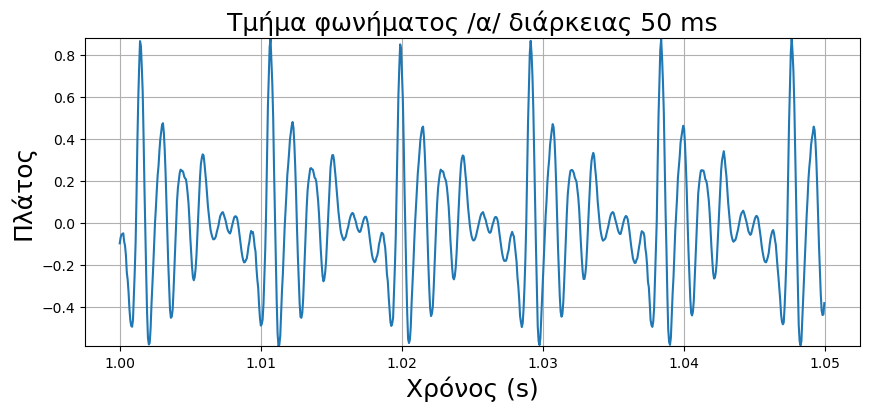

In [8]:
start = 1                      # Έστω ότι το τμήμα μας αρχίζει στο 1 sec
finish = 1.05                  # ...και τελειώνει μετά από 0.05 sec = 50 ms

start_s = round(start*Fs)      # Mετατρέπουμε την αρχή σε δείγματα
finish_s = round(finish*Fs)    # Μετατρέπουμε το τέλος σε δείγματα

segment = s[start_s:finish_s]          # "Κόβουμε"/απομονώνουμε το τμήμα που μας ενδιαφέρει από το αρχικό σήμα s
t = np.arange(start_s, finish_s, 1)/Fs # Άξονας του χρόνου (1, 1.05) s

plt.figure(figsize=(10,4))     # Οπτικοποίηση
plt.plot(t, segment)              
plt.ylim([min(segment), max(segment)])
plt.grid()
plt.title('Τμήμα φωνήματος /α/ διάρκειας 50 ms', fontsize=18)
plt.xlabel("Χρόνος (s)", fontsize=18)
plt.ylabel("Πλάτος", fontsize=18)
plt.show()


* Στη μεταβλητή ``segment`` έχετε ένα τμήμα της φωνής σας διάρκειας $50$ ms. Χρησιμοποιήστε τον κώδικα ανάλυσης Fourier (συνάρτηση ``ctft`` που έχει ήδη γίνει ``import`` για σας στο πρώτο κελί του εργαστηρίου) για να αναλύσετε το σήμα σας στην περιοχή συχνοτήτων από $2000$ ως $4000$ Hz και να βρείτε το μετασχηματισμό Fourier και να απεικονίστε γραφικά το φάσμα πλάτους και το φάσμα φάσης. H προαναφερθείσα συνάρτηση δέχεται τρια ορίσματα:

1. Το σήμα ομιλίας
2. Τον άξονα του χρόνου (σας δίνεται παρακάτω)
3. Τον άξονα της συχνότητας (πρέπει να τον κατασκευάσετε εσείς, με βάση την προηγούμενη περιγραφή)

* Στον κώδικα ανάλυσης, χρησιμοποιήστε μικρό βήμα στη συχνότητα, της τάξης του $0.1$ Hz, όπως σας δίνεται:

In [5]:
Df = 0.1                    # Βήμα στη συχνότητα
f = np.arange(2000, 4000, Df) # INSERT CODE HERE      # Κατασκευάστε τον άξονα συχνοτήτων από 2000 ως 4000 Hz (χρησιμοποιήστε τη συνάρτηση np.arange)

* Αν το φάσμα πλάτους που θα δείτε, παρουσιάσει μια συμμετρία ως προς τη συχνότητα $3000$ Hz, τότε υπάρχει κάποια απειροελάχιστη πιθανότητα να συνδέεται με κάποια πιθανή μελλοντική παθολογία.

In [6]:
t = np.arange(start=start_s, stop=finish_s, step=1)/Fs   # άξονας χρόνου

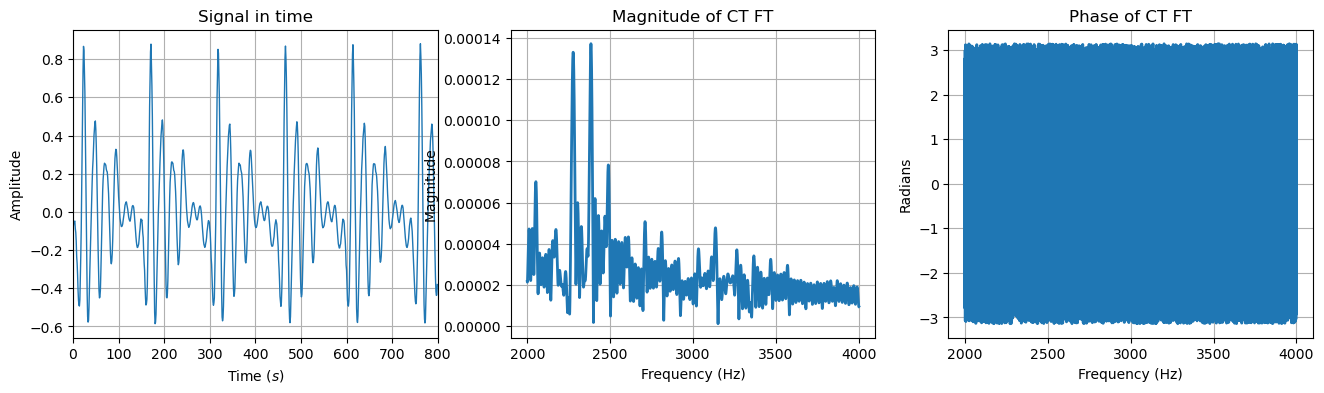

In [7]:
X, absX, angX = ctft(segment, t, f) # INSERT CODE HERE - καλέστε τη συνάρτηση ctft με κατάλληλα ορίσματα

Αν τα κάνετε όλα σωστά, θα πάρετε - για το δικό μας σήμα - ένα σχήμα όπως παρακάτω:

![alt text](./files/FTpath_n.png "Title")

Παρατηρούμε ότι κάτι αχνοφαίνεται 😯 γύρω από τα $3000$ Hz (για το δικό μας σήμα - για το δικό σας? 😁) Απαντήστε παρακάτω:

### Απάντηση:

---
---